In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress
from pathlib import Path

DATA_PATH = Path("../data/processed")

nav = pd.read_csv(DATA_PATH/"nav_history.csv")
benchmark = pd.read_csv(DATA_PATH/"benchmark_data.csv")
expense = pd.read_csv(DATA_PATH/"expense_ratio.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

print("Data Loaded Successfully")

Data Loaded Successfully


Data Loaded Successfully

NAV Columns:
['date', 'scheme_code', 'nav', 'scheme_name']

First 5 Rows:


,date,scheme_code,nav,scheme_name
0,2019-01-01,118632,112.0412,Nippon India Large Cap Fund - Direct - Growth
1,2019-01-02,118632,123.7188,Nippon India Large Cap Fund - Direct - Growth
2,2019-01-03,118632,127.1850,Nippon India Large Cap Fund - Direct - Growth
3,2019-01-04,118632,127.9349,Nippon India Large Cap Fund - Direct - Growth
4,2019-01-05,118632,122.5113,Nippon India Large Cap Fund - Direct - Growth



Daily Return Created Successfully

First 10 Rows with Daily Return:


,date,scheme_code,scheme_name,nav,daily_return
0,2019-01-01,118632,Nippon India Large Cap Fund - Direct - Growth,112.0412,NaN
1,2019-01-02,118632,Nippon India Large Cap Fund - Direct - Growth,123.7188,0.104226
2,2019-01-03,118632,Nippon India Large Cap Fund - Direct - Growth,127.1850,0.028017
3,2019-01-04,118632,Nippon India Large Cap Fund - Direct - Growth,127.9349,0.005896
4,2019-01-05,118632,Nippon India Large Cap Fund - Direct - Growth,122.5113,-0.042393
5,2019-01-07,118632,Nippon India Large Cap Fund - Direct - Growth,154.9922,0.265126
6,2019-01-08,118632,Nippon India Large Cap Fund - Direct - Growth,160.1356,0.033185
7,2019-01-10,118632,Nippon India Large Cap Fund - Direct - Growth,144.6866,-0.096474
8,2019-01-11,118632,Nippon India Large Cap Fund - Direct - Growth,149.7058,0.034690
9,2019-02-01,118632,Nippon India Large Cap Fund - Direct - Growth,113.8001,-0.239842


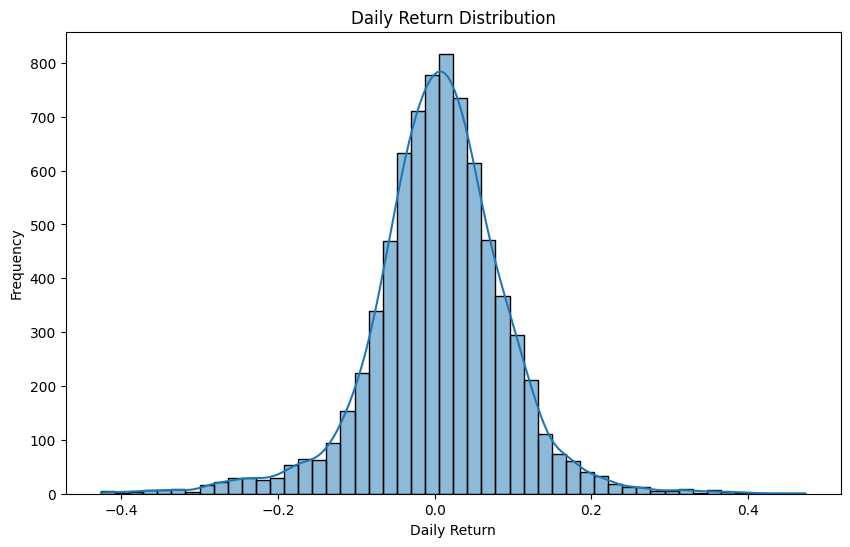

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress
from pathlib import Path

# ==========================================
# LOAD DATA
# ==========================================

DATA_PATH = Path("../data/processed")

nav = pd.read_csv(DATA_PATH / "nav_history.csv")
benchmark = pd.read_csv(DATA_PATH / "benchmark_data.csv")
expense = pd.read_csv(DATA_PATH / "expense_ratio.csv")

# Convert date columns
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

print("Data Loaded Successfully")

# ==========================================
# INSPECT DATA
# ==========================================

print("\nNAV Columns:")
print(nav.columns.tolist())

print("\nFirst 5 Rows:")
display(nav.head())

# ==========================================
# CALCULATE DAILY RETURNS
# daily_return = (NAV_t / NAV_t-1) - 1
# ==========================================

nav = nav.sort_values(["scheme_code", "date"])

nav["daily_return"] = (
    nav.groupby("scheme_code")["nav"]
       .pct_change()
)

print("\nDaily Return Created Successfully")

print("\nFirst 10 Rows with Daily Return:")
display(
    nav[["date", "scheme_code", "scheme_name", "nav", "daily_return"]]
    .head(10)
)

# ==========================================
# DAILY RETURN DISTRIBUTION
# ==========================================

plt.figure(figsize=(10, 6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [7]:
cagr_results = []

for scheme in nav["scheme_code"].unique():

    temp = nav[
        nav["scheme_code"] == scheme
    ].sort_values("date")

    latest = temp.iloc[-1]

    for years in [1,3,5]:

        start_date = latest["date"] - pd.DateOffset(years=years)

        hist = temp[
            temp["date"] >= start_date
        ]

        if len(hist) > 0:

            start_nav = hist.iloc[0]["nav"]
            end_nav = latest["nav"]

            cagr = (
                (end_nav/start_nav)
                **(1/years)
                - 1
            )

            cagr_results.append([
                scheme,
                years,
                cagr
            ])

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "scheme_code",
        "years",
        "cagr"
    ]
)

cagr_df.head()

,scheme_code,years,cagr
0,118632,1,-0.181681
1,118632,3,0.029633
2,118632,5,0.055868
3,118778,1,0.384099
4,118778,3,0.126509


In [8]:
RF = 0.065
sharpe = []

for scheme in nav["scheme_code"].unique():

    temp = nav[
        nav["scheme_code"] == scheme
    ]

    mean_return = (
        temp["daily_return"]
        .mean()
        *252
    )

    std_return = (
        temp["daily_return"]
        .std()
    )

    sr = (
        (mean_return-RF)
        / std_return
    ) * np.sqrt(252)

    sharpe.append([
        scheme,
        sr
    ])

sharpe_df = pd.DataFrame(
    sharpe,
    columns=[
        "scheme_code",
        "sharpe_ratio"
    ]
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,scheme_code,sharpe_ratio
3,118989,297.832208
8,119802,286.687705
7,119551,286.515062
9,120178,269.659052
11,120503,260.172528


In [9]:
sortino = []

for scheme in nav["scheme_code"].unique():

    temp = nav[
        nav["scheme_code"] == scheme
    ]

    downside = temp[
        temp["daily_return"] < 0
    ]["daily_return"]

    downside_std = downside.std()

    annual_return = (
        temp["daily_return"]
        .mean()
        *252
    )

    ratio = (
        (annual_return-RF)
        / downside_std
    ) * np.sqrt(252)

    sortino.append([
        scheme,
        ratio
    ])

sortino_df = pd.DataFrame(
    sortino,
    columns=[
        "scheme_code",
        "sortino_ratio"
    ]
)

In [10]:
benchmark["nifty_return"] = (
    benchmark["nifty100"]
    .pct_change()
)
alpha_beta = []

for scheme in nav["scheme_code"].unique():

    fund = nav[
        nav["scheme_code"] == scheme
    ][["date","daily_return"]]

    merged = pd.merge(
        fund,
        benchmark[
            ["date","nifty_return"]
        ],
        on="date"
    ).dropna()

    if len(merged) > 50:

        slope, intercept, r, p, se = (
            linregress(
                merged["nifty_return"],
                merged["daily_return"]
            )
        )

        alpha = intercept*252
        beta = slope

        alpha_beta.append([
            scheme,
            alpha,
            beta
        ])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "scheme_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [11]:
drawdowns = []

for scheme in nav["scheme_code"].unique():

    temp = nav[
        nav["scheme_code"] == scheme
    ].copy()

    temp["running_max"] = (
        temp["nav"].cummax()
    )

    temp["drawdown"] = (
        temp["nav"]
        / temp["running_max"]
        - 1
    )

    drawdowns.append([
        scheme,
        temp["drawdown"].min()
    ])

dd_df = pd.DataFrame(
    drawdowns,
    columns=[
        "scheme_code",
        "max_drawdown"
    ]
)

In [12]:
score = (
    sharpe_df
    .merge(alpha_beta_df)
    .merge(dd_df)
    .merge(expense[
        ["scheme_code",
         "expense_ratio_direct_pct"]
    ])
)
score["sharpe_rank"] = (
    score["sharpe_ratio"]
    .rank(pct=True)
)

score["alpha_rank"] = (
    score["alpha"]
    .rank(pct=True)
)

score["dd_rank"] = (
    (-score["max_drawdown"])
    .rank(pct=True)
)

score["expense_rank"] = (
    (-score["expense_ratio_direct_pct"])
    .rank(pct=True)
)
score["fund_score"] = (

      25*score["sharpe_rank"]

    + 20*score["alpha_rank"]

    + 15*score["expense_rank"]

    + 10*score["dd_rank"]

)
score["fund_score"] = (
    score["fund_score"]
    / score["fund_score"].max()
    *100
)

score.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

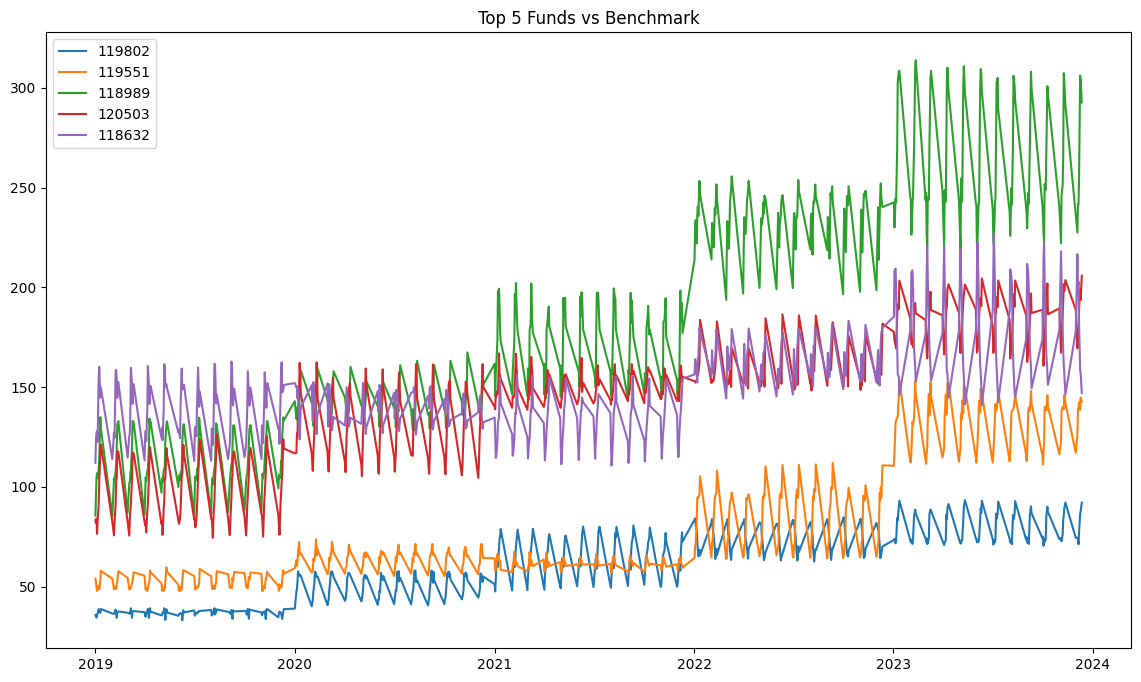

In [13]:
top5 = (
    score.sort_values(
        "fund_score",
        ascending=False
    )
    .head(5)
)["scheme_code"]
plt.figure(figsize=(14,8))

for scheme in top5:

    temp = nav[
        nav["scheme_code"] == scheme
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(scheme)
    )

plt.legend()

plt.title(
    "Top 5 Funds vs Benchmark"
)

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
print("Generated:")

print(
    Path("../data/processed/fund_scorecard.csv").exists()
)

print(
    Path("../data/processed/alpha_beta.csv").exists()
)

print(
    Path("../reports/charts/benchmark_comparison.png").exists()
)

Generated:
True
True
True
